In [ ]:

import argparse
import os
import numpy as np
import matplotlib.pyplot as plt
import orbax.checkpoint
from flax.training import orbax_utils

def plot_training_progress(results_path, EnvName):
    """
    Loads training results and plots the mean episodic return over training timesteps.

    Args:
        results_path (str): Path to the directory where the training results are stored.
    """
    print(f"Loading results from {results_path}...")
    
    # Load the results using orbax
    orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
    restored_data = orbax_checkpointer.restore(results_path)
    
    print("Results loaded successfully.")
    
    metrics = restored_data['out']['metric']
    args = restored_data['args']
    num_envs = args.get('num_envs', 1)

    # Extract relevant metrics
    # The metrics are stored only for completed episodes, so we need to filter
    returned_episode = metrics.get('returned_episode')
    if returned_episode is None:
        print("Error: 'returned_episode' not found in metrics.")
        return

    # Get the returns and timesteps for completed episodes
    # Flatten the arrays to make it easier to work with
    returned_episode_returns = metrics.get('returned_discounted_episode_returns')[returned_episode].flatten()
    timesteps = metrics.get('timestep')[returned_episode].flatten() * num_envs

    if len(timesteps) == 0:
        print("No completed episodes found in the metrics. Cannot generate plot.")
        return

    # Sort the data by timestep
    sorted_indices = np.argsort(timesteps)
    sorted_timesteps = timesteps[sorted_indices]
    sorted_returns = returned_episode_returns[sorted_indices]

    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.plot(sorted_timesteps, sorted_returns, label='Discounted Episodic Return', alpha=0.2, color='blue')
    
    # For better visualization, you might want to plot a moving average
    window_size = 50
    if len(sorted_returns) >= window_size:
        moving_avg = np.convolve(sorted_returns, np.ones(window_size)/window_size, mode='valid')
        # Adjust timesteps for moving average plot
        moving_avg_timesteps = sorted_timesteps[window_size-1:]
        plt.plot(moving_avg_timesteps, moving_avg, label=f'Moving Average (window={window_size})', color='red', linestyle='--')


    plt.title(f'Discounted Episodic Return over Timesteps ({EnvName})')
    plt.xlabel('Timesteps')
    plt.ylabel('Episodic Return')
    plt.grid(True)
    plt.legend()
    
    # Save the plot
    png_path = "plots"
    os.makedirs(png_path, exist_ok=True)
    plot_filename = os.path.join(png_path, f"{EnvName}_training_progress.png")
    plt.tight_layout()
    plt.savefig(plot_filename)
    print(f"Plot saved to {plot_filename}")
    plt.show()









In [21]:
results_path = "/home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/rocksample_7_8_seed(2024)_time(20250731-154403)_2b4fcdbf78add77a258884e5436772ae"



Loading results from /home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/rocksample_7_8_seed(2024)_time(20250731-154403)_2b4fcdbf78add77a258884e5436772ae...
Results loaded successfully.
Plot saved to /home/users/ucakir/Experiments_POMDP_DRL/pobax/results/batch_ppo_test/training_rewards_RS(7,8).png


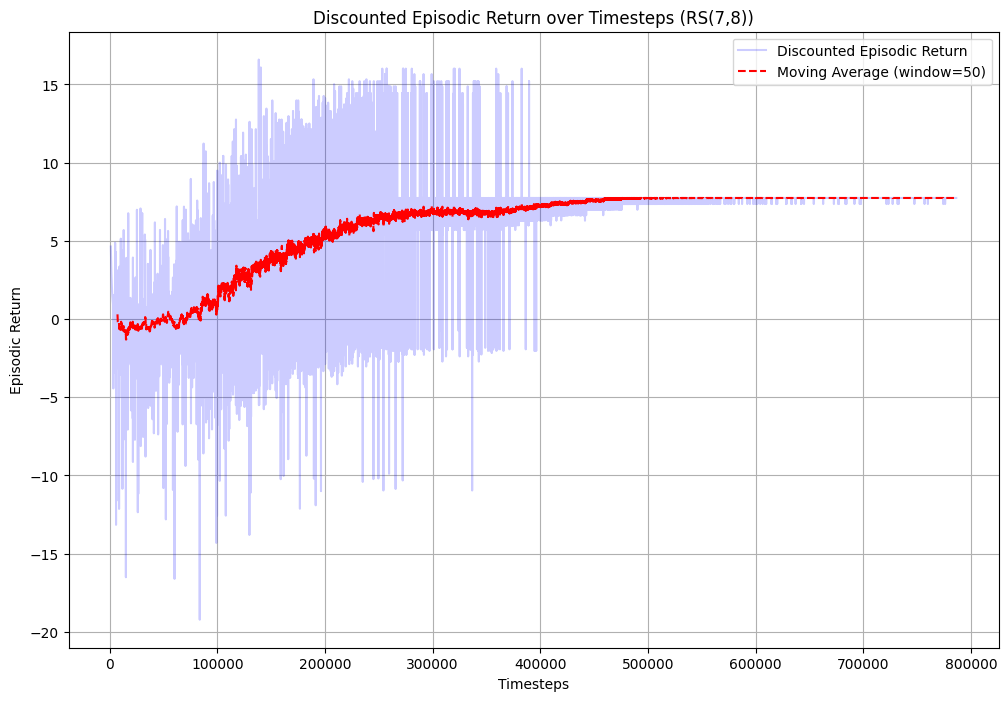

In [22]:
plot_training_progress(results_path, "RS(7,8)")  # Example usage with a specific environment name